# Data Mining — Linear Regression — Mini-Project 1 (Energy Consumption)

**Course:** [CSEN911] Data Mining (Winter 2025)  
**Instructor:** Dr. Ayman Alserafi  
**Due:** 24 October 2025, 11:59 PM

**Dataset:** `energy_data.csv`  


> **Instructions:** For every step, write your own explanations and justifications and visualization in the provided Markdown prompts.




***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: Hager Badran

ID: 58-7418

Tutorial: 3

---

Name:

ID:

Tutorial:

---


The dataset contains building-level energy readings and contextual attributes.

Each row represents a building observation. Columns include:

<div style="font-size:20px;">

| **Column** | **Description** |
|-------------|-----------------|
| **Building_ID** | Unique identifier for each building record. Used to distinguish one building entry from another. |
| **Building_Type** | Category describing the primary use of the building (e.g., Residential, Commercial, Industrial, Educational, etc.). |
| **Governorate** | The administrative region (governorate) where the building is located (e.g., Cairo, Giza, Alexandria). |
| **Neighborhood** | The smaller district or local area within the governorate where the building is located. |
| **Day_of_Week** | The day on which the energy consumption measurement was recorded (e.g., Sunday, Monday, etc.). |
| **Occupancy_Level** | The relative number of occupants or activity level in the building, typically categorized as *Low*, *Medium*, or *High*. |
| **Appliances_Usage_Level** | Indicates how intensively appliances are used in the building *Low*, *Medium*, or *High*. |
| **SquareFootage** | The total floor area of the building (numeric). Serves as a proxy for building size, often influencing energy usage. |
| **Last_Maintenance_Date** | The date of the last maintainance done on the building. |
| **Average_Temperature** | The average ambient temperature (in °C) recorded during the data period. |
| **Energy_Consumption** | The total energy used by the building, typically measured in kilowatt-hours (kWh).|

</div>


## Importing Libraries & Dataset

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh


## Data Inspection

Perform data inspection tasks here (recommended for data understanding).

In [44]:
# Check data types and null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Building_ID             1100 non-null   object 
 1   Building_Type           1100 non-null   object 
 2   Governorate             1100 non-null   object 
 3   Neighborhood            1100 non-null   object 
 4   Day_of_Week             1100 non-null   object 
 5   Occupancy_Level         1100 non-null   object 
 6   Appliances_Usage_Level  1100 non-null   object 
 7   SquareFootage           1100 non-null   object 
 8   Last_Maintenance_Date   1100 non-null   object 
 9   Average_Temperature     1100 non-null   float64
 10  Energy_Consumption      1100 non-null   object 
dtypes: float64(1), object(10)
memory usage: 94.7+ KB


In [45]:
#number of null values in columns
print("\nExplicit Null Counts:")
print(df.isnull().sum())


Explicit Null Counts:
Building_ID               0
Building_Type             0
Governorate               0
Neighborhood              0
Day_of_Week               0
Occupancy_Level           0
Appliances_Usage_Level    0
SquareFootage             0
Last_Maintenance_Date     0
Average_Temperature       0
Energy_Consumption        0
dtype: int64


In [46]:
#descriptive statistics of the dataset
df.describe(include='all')

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
count,1100,1100,1100,1100,1100,1100,1100,1100,1100,1100.000000,1100
unique,1100,3,3,848,42,3,3,1095,727,NaN,1100
top,BLD-2099-GL,Residential,Alexandria,Smouha,Sunday,High,Low,49653m2,2024-12-31,NaN,4722.59 kWh
freq,1,459,537,45,54,368,381,2,89,NaN,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.499404,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.154008,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.910000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.072500,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.985000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.210000,NaN


In [22]:
# Check unique values and value counts for categorical columns
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].dtype == 'object':
        print(df[col].value_counts().head(5))
    print("-" * 30)

Building_ID: 1100 unique values
Building_ID
BLD-2099-GL    1
BLD-1000-UD    1
BLD-1001-AX    1
BLD-1002-IH    1
BLD-1003-HE    1
Name: count, dtype: int64
------------------------------
Building_Type: 3 unique values
Building_Type
Residential    349
Commercial     325
Industrial     316
Name: count, dtype: int64
------------------------------
Governorate: 3 unique values
Governorate
Alexandria    310
Giza          293
Cairo         270
Name: count, dtype: int64
------------------------------
Neighborhood: 848 unique values
Neighborhood
Smouha         45
Gleem          44
Dokki          41
Mohandessin    38
New Cairo      32
Name: count, dtype: int64
------------------------------
Day_of_Week: 42 unique values
Day_of_Week
Sunday      54
Saturday    53
saturDAY    49
SuNday      48
SATURDAY    47
Name: count, dtype: int64
------------------------------
Occupancy_Level: 3 unique values
Occupancy_Level
High      368
Low       368
Medium    364
Name: count, dtype: int64
--------------------

## Data Pre-Processing & Cleaning

_Apply any data preprocessing and/or feature engineering below. Show/output the changes to the dataset._

1.Resolving inconsistencies in categorical & numerical columns

In [47]:
# 1. Clean SquareFootage
#remove non-numeric chars and it will still be int as it is not decimal
# The units are removed from `SquareFootage` (e.g., '1500m2' becomes 1500) to make it consistent
df['SquareFootage'] = df['SquareFootage'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['SquareFootage'] = pd.to_numeric(df['SquareFootage'], errors='coerce')

# 2. Clean Energy_Consumption
#remove ' kWh' and convert to float
df['Energy_Consumption'] = df['Energy_Consumption'].astype(str).str.replace(' kWh', '').astype(float)

# 3. Standardize categorical columns to ensure consistency
categorical_cols = ['Building_Type', 'Governorate', 'Day_of_Week', 'Occupancy_Level', 'Appliances_Usage_Level']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.title()

# 4. Clean Neighborhood: remove leading spaces, '+' and numbers
df['Neighborhood'] = df['Neighborhood'].astype(str).str.replace(r'^\s*[\+\d]+', '', regex=True).str.strip()

# Display changes
print("Data types after cleaning units:")
print(df[['SquareFootage', 'Energy_Consumption']].dtypes)
print("\nSample categorical data after standardization:")
print(df[['Building_Type', 'Neighborhood', 'Day_of_Week']].head())
print(f"Unique values in Day_of_Week after cleaning: {df['Day_of_Week'].nunique()}")
print(f"SquareFootage Dtype: {df['SquareFootage'].dtype}")

Data types after cleaning units:
SquareFootage           int64
Energy_Consumption    float64
dtype: object

Sample categorical data after standardization:
  Building_Type   Neighborhood Day_of_Week
0   Residential         Smouha   Wednesday
1    Commercial  Mohandessin14     Tuesday
2    Industrial      New Cairo      Sunday
3   Residential          Dokki     Tuesday
4    Commercial         Smouha      Monday
Unique values in Day_of_Week after cleaning: 7
SquareFootage Dtype: int64


2. Resolving Null Values

In [43]:
#Filling missing values for categorical columns
#Using the mode " mos† frequent "
for col in ['Building_Type', 'Governorate']:
    # Check if column has nulls before attempting imputation
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

#Filling missing values for numerical columns
#Using the mean " average "
numerical_impute_cols = ['Average_Temperature', 'SquareFootage', 'Energy_Consumption']
for col in numerical_impute_cols:
    if df[col].isnull().any():
        mean_val = df[col].mean()
        df[col].fillna(mean_val, inplace=True)

# Verify null value resolution
print("Null counts after imputation:")
print(df.isnull().sum())

Null counts after imputation:
Building_ID               0
Building_Type             0
Governorate               0
Neighborhood              0
Day_of_Week               0
Occupancy_Level           0
Appliances_Usage_Level    0
SquareFootage             0
Last_Maintenance_Date     0
Average_Temperature       0
Energy_Consumption        0
dtype: int64


/tmp/ipython-input-340788767.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-340788767.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

3. Feature Engineering: Days Since Last Maintenance

In [50]:
#converting Last_Maintenance_Date to datetime object
df['Last_Maintenance_Date'] = pd.to_datetime(df['Last_Maintenance_Date'])

#choose a reference date
reference_date = pd.to_datetime('2025-10-24')

# Calculate the difference in days
df['Days_since_last_maintenance'] = (reference_date - df['Last_Maintenance_Date']).dt.days
print(df[['Last_Maintenance_Date', 'Days_since_last_maintenance']].head())

  Last_Maintenance_Date  Days_since_last_maintenance
0            2020-01-01                         2123
1            2022-02-24                         1338
2            2021-02-22                         1705
3            2023-07-30                          817
4            2022-08-12                         1169


4. Feature Engineering: Day_type

5. Selecting suitable columns for the modelling step

6.Applying and justifying appropriate categorical encoding methods for the modelling step

## Exploratory Data Analysis

**Q1:** What are the most popular neighborhoods? plot all and order them on the graph (mention top 3)

**Visualization**

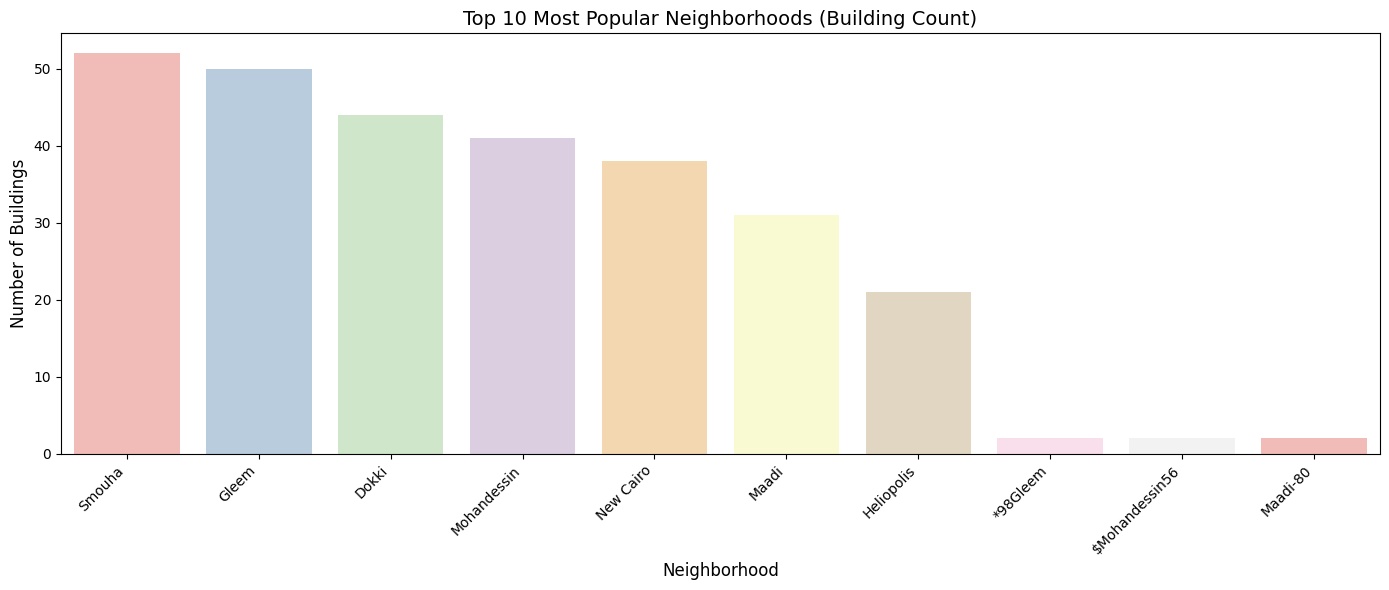

Top 3 Most Popular Neighborhoods:
Neighborhood
Smouha    52
Gleem     50
Dokki     44
Name: count, dtype: int64


In [57]:
# plot diagram
plt.figure(figsize=(14, 6))
# Filter out any 'Nan' string values from the cleaning step if necessary
neighborhood_counts = df[df['Neighborhood'] != 'Nan']['Neighborhood'].value_counts().sort_values(ascending=False)
x_labels = neighborhood_counts.index[:10]
y_values = neighborhood_counts.values[:10]
sns.barplot(x=neighborhood_counts.index[:10], y=neighborhood_counts.values[:10], hue=x_labels, palette='Pastel1') # Plotting Top 10 for readability
plt.title('Top 10 Most Popular Neighborhoods (Building Count)', fontsize=14)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Number of Buildings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_3_neighborhoods = neighborhood_counts.head(3)
print("Top 3 Most Popular Neighborhoods:")
print(top_3_neighborhoods)

**Answer for Q1:** Top 3 Most Popular Neighborhoods:
Smouha with 52,
Gleem with 50 and
Dokki with 44 buildings

**Q2:** Show the distribution of the energy consumption of each Building type.

Which type have the widest distribution of energy consumption?

Which (on average) has the highest consumption?.

**Visualization**

**Answer for Q2:** _Your answer here_

**Q3:** How does the building size affect energy consumption?

**Visualization**

**Answer for Q3:** _Your answer here_

**Q4:** Do buildings consume more energy if not maintained frequently?

**Visualization**

**Answer for Q4:** _Your answer here_

**Q5:** Are all the numerical variables normally distributed, or is there any skewness?

**Visualization**

**Answer for Q5:** _Your answer here_

**Q6:** What is multicollinearity? And why is it a problem for linear regression? Does this problem exist in this
dataset?

**Visualization**

**Answer for Q6:** _Your answer here_

## Data Preparation for Modelling

_Apply any additional data preparation steps needed before modelling below. Show/output the changes to the dataset._

## Modelling

_Apply the linear regression model below._

## Model Evaluation

Evaluate the model you applied.

## Conclusion and Recommendations

Comment on the model performance and your findings from model evaluation. State the problems (if any) and suggest possible solutions. Would you recommend this model for an electrcity company aiming to estimate the energy levels of each building?

**Answer**: your answer here.